<a href="https://colab.research.google.com/github/hufsaim/T03108701/blob/main/notebook_2025/Lab02_cost_of_computation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import cupy as cp
import time

- 이번 실습은 런타임 -> 런타임 유형변경 -> 하드웨어 가속기에서 GPU 선택(예: T4 GPU) 과정을 통해 colab에서 GPU를 활용할 수 있도록 해야 합니다.

In [ ]:
!nvidia-smi

Thu Oct 16 08:31:11 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Matrix A, vector b 정의하기 (numpy)

In [ ]:
n=2
A = np.random.randint(-10,10,size=(n,n))
b = np.random.randint(-10,10,size=(n,1))
print('A=\n',A)
print('b=\n',b)

A=
 [[ 6 -3]
 [ 2  7]]
b=
 [[-2]
 [-9]]


### Ax = b 의 solution x를 계산하기 (numpy)

In [ ]:
x = np.linalg.solve(A,b)
print('solution of Ax = b: \n',x)

solution of Ax = b: 
 [[-0.85416667]
 [-1.04166667]]


### Matrix A, vector b를 정의하고 Ax = b의 solution x를 계산하기 (cupy - GPU활용)

In [ ]:
n = 2
A = cp.random.randint(-10,10,size=(n,n))
b = cp.random.randint(-10,10,size=(n,1))
print('A=\n',A)
print('b=\n',b)

x = cp.linalg.solve(A,b)
print('solution of Ax = b: \n',x)

A=
 [[ 6 -7]
 [-7 -5]]
b=
 [[-7]
 [ 2]]
solution of Ax = b: 
 [[-0.62025316]
 [ 0.46835443]]


### Matrix A의 inverse Matrix를 계산하기 (numpy - CPU활용)

In [ ]:
n = 2
A = np.random.randint(-10,10,size=(n,n))
print('A=\n',A)

A_inv = np.linalg.inv(A)
print('inverse of A=\n',A_inv)

A=
 [[ 2  0]
 [ 9 -6]]
inverse of A=
 [[ 0.5         0.        ]
 [ 0.75       -0.16666667]]


### Matrix A의 inverse Matrix를 계산하기 (cupy - GPU활용)


In [ ]:
n = 2
A = cp.random.randint(-10,10,size=(n,n))
print('A=\n',A)

A_inv = cp.linalg.inv(A)
print('inverse of A=\n',A_inv)

A=
 [[ 4  6]
 [-2 -5]]
inverse of A=
 [[ 0.625  0.75 ]
 [-0.25  -0.5  ]]


### CPU를 사용한 풀이 (for large N)

In [ ]:
N = 10000
print(N,'x',N,' matrix:')
A = np.random.randint(-10,10,size=(N,N))
b = np.random.randint(-10,10,size=(N,1))
#print('\ndet(A)=',np.linalg.det(A))

s0 = time.time()
x = np.linalg.solve(A,b)
solve_time = time.time() -s0
print('computation time (solution of linear equation)= ',solve_time,' sec')

s0 = time.time()
x = np.linalg.inv(A)
solve_time = time.time() -s0
print('computation time (inverse matrix) = ',solve_time,' sec')

10000 x 10000  matrix:
computation time (solution of linear equation)=  22.707051753997803  sec
computation time (inverse matrix) =  79.45678448677063  sec


### GPU를 사용한 풀이 (for large N)



In [ ]:
N = 10000
print(N,'x',N,' matrix:')
Ac = cp.random.randint(-10,10,size=(N,N))
bc = cp.random.randint(-10,10,size=(N,1))
#print('\ndet(A)=',np.linalg.det(A))

s0 = time.time()
xc = cp.linalg.solve(Ac,bc)
solve_time = time.time() -s0
print('computation time (solution of linear equation) = ',solve_time,' sec')

s0 = time.time()
xc = cp.linalg.inv(Ac)
solve_time = time.time() -s0
print('computation time (inverse matrix) = ',solve_time,' sec')

10000 x 10000  matrix:
computation time (solution of linear equation) =  1.5590651035308838  sec
computation time (inverse matrix) =  3.447037935256958  sec


## Matrix multiplication

In [ ]:
n = 2
A = np.random.randint(-10,10,size=(n,n))
B = np.random.randint(-10,10,size=(n,n))
print('A=\n',A)
print('B=\n',B)

AB = np.matmul(A,B)
print('AB=\n',AB)


A=
 [[-2  4]
 [ 2 -1]]
B=
 [[-9  8]
 [-9  8]]
AB=
 [[-18  16]
 [ -9   8]]


### CPU를 사용한 AB computation (for large N)

In [ ]:
N = 2000
A = np.random.randint(-10,10,size=(N,N))
B = np.random.randint(-10,10,size=(N,N))
print('shape of A: ',A.shape)
print('shape of B:',B.shape)

s0 = time.time()
AB = np.matmul(A, B)
compu_time=time.time() - s0
print('computation time = ', compu_time,' sec')

shape of A:  (2000, 2000)
shape of B: (2000, 2000)
computation time =  11.320974588394165  sec


### GPU를 사용한 AB computation (for large N)

In [ ]:
N = 2000
A = cp.random.randint(-10,10,size=(N,N))
B = cp.random.randint(-10,10,size=(N,N))
print('shape of A: ',A.shape)
print('shape of B:',B.shape)

s0 = time.time()
AB = cp.matmul(A, B)
compu_time=time.time() - s0
print('computation time = ', compu_time,' sec')

shape of A:  (2000, 2000)
shape of B: (2000, 2000)
computation time =  0.0031516551971435547  sec


## Exercise
- N = 10, 100, 1000, 10000 인 경우 numpy로 Ax=b를 푸는 시간과 cupy로 Ax=b를 푸는데 걸리는 시간을 각각 5번씩 반복하여 측정하여 평균을 구해보기.


In [ ]:
# Exercise 1: Ax = b solve time (NumPy vs CuPy), 5-run average
import time
import numpy as np
import cupy as cp

def gpu_sync():
    cp.cuda.Stream.null.synchronize()

def make_spd_like(N, xp=np, dtype=np.float32, seed=0, reg=1e-3):
    """수치 안전성을 위한 약한 대각 성분(reg)을 더해 준 실대칭 행렬 생성"""
    rs = np.random.RandomState(seed)
    A = rs.randn(N, N).astype(dtype)
    # xp가 cupy인 경우로 캐스팅
    A = xp.asarray(A)
    # 대칭화
    A = (A + A.T) / 2
    # 조건수 개선(약한 정칙화)
    A = A + reg * xp.eye(N, dtype=dtype)
    # b 생성
    b = xp.asarray(rs.randn(N, 1).astype(dtype))
    return A, b

def bench_solve_numpy(N, reps=5, dtype=np.float32, seed=0, reg=1e-3):
    A, b = make_spd_like(N, xp=np, dtype=dtype, seed=seed, reg=reg)
    # warm-up
    _ = np.linalg.solve(A, b)
    times = []
    for _ in range(reps):
        t0 = time.perf_counter()
        x = np.linalg.solve(A, b)
        times.append(time.perf_counter() - t0)
    return float(np.mean(times)), float(np.std(times))

def bench_solve_cupy(N, reps=5, dtype=np.float32, seed=0, reg=1e-3):
    A, b = make_spd_like(N, xp=cp, dtype=dtype, seed=seed, reg=reg)
    # warm-up (GPU 비동기 → 동기화)
    _ = cp.linalg.solve(A, b); gpu_sync()
    times = []
    for _ in range(reps):
        t0 = time.perf_counter()
        x = cp.linalg.solve(A, b)
        gpu_sync()
        times.append(time.perf_counter() - t0)
    return float(np.mean(times)), float(np.std(times))

Ns = [10, 100, 1000, 10000]  # 환경에 따라 10000은 메모리 부족 가능
dtype = np.float32            # 메모리 절감 및 GPU 가속 친화
reps = 5

results = []
for N in Ns:
    try:
        np_mean, np_std = bench_solve_numpy(N, reps=reps, dtype=dtype, seed=0)
    except Exception as e:
        np_mean, np_std = None, None
        print(f"[NumPy][N={N}] 실패: {type(e).__name__} - {e}")

    try:
        cu_mean, cu_std = bench_solve_cupy(N, reps=reps, dtype=dtype, seed=0)
    except cp.cuda.memory.OutOfMemoryError as e:
        cu_mean, cu_std = None, None
        print(f"[CuPy ][N={N}] 메모리 부족(OOM): {e}")
    except Exception as e:
        cu_mean, cu_std = None, None
        print(f"[CuPy ][N={N}] 실패: {type(e).__name__} - {e}")

    results.append((N, np_mean, np_std, cu_mean, cu_std))

# 표 형태 출력
print(f"{'N':>8} | {'NumPy mean±std (s)':>24} | {'CuPy mean±std (s)':>24}")
print("-"*64)
for N, n_m, n_s, c_m, c_s in results:
    n_txt = "FAIL" if n_m is None else f"{n_m:.6f}±{n_s:.6f}"
    c_txt = "OOM/FAIL" if c_m is None else f"{c_m:.6f}±{c_s:.6f}"
    print(f"{N:8d} | {n_txt:>24} | {c_txt:>24}")


       N |       NumPy mean±std (s) |        CuPy mean±std (s)
----------------------------------------------------------------
      10 |        0.000016±0.000007 |        0.000236±0.000067
     100 |        0.000101±0.000005 |        0.000541±0.000010
    1000 |        0.025312±0.000358 |        0.007938±0.000057
   10000 |       18.905944±0.493754 |        0.286179±0.003816


- N = 10, 100, 1000, 10000 인 경우 numpy로 A의 inverse matrix를 구하는 시간과 cupy로 A의 inverse matrix를 구하는 데 걸리는 시간을 각각 5번씩 반복하여 측정하여 평균을 구해보기.

In [ ]:
# Exercise 2: inverse(A) time (NumPy vs CuPy), 5-run average
import time
import numpy as np
import cupy as cp

def gpu_sync():
    cp.cuda.Stream.null.synchronize()

def make_reg_matrix(N, xp=np, dtype=np.float32, seed=0, reg=1e-3):
    """무작위 행렬에 약한 정칙화(reg*I) 추가하여 역행렬 실패 확률 완화"""
    rs = np.random.RandomState(seed)
    A = rs.randn(N, N).astype(dtype)
    A = xp.asarray(A)
    A = A + reg * xp.eye(N, dtype=dtype)
    return A

def bench_inv_numpy(N, reps=5, dtype=np.float32, seed=0, reg=1e-3):
    A = make_reg_matrix(N, xp=np, dtype=dtype, seed=seed, reg=reg)
    # warm-up
    _ = np.linalg.inv(A)
    times = []
    for _ in range(reps):
        t0 = time.perf_counter()
        Ainv = np.linalg.inv(A)
        times.append(time.perf_counter() - t0)
    return float(np.mean(times)), float(np.std(times))

def bench_inv_cupy(N, reps=5, dtype=np.float32, seed=0, reg=1e-3):
    A = make_reg_matrix(N, xp=cp, dtype=dtype, seed=seed, reg=reg)
    # warm-up
    _ = cp.linalg.inv(A); gpu_sync()
    times = []
    for _ in range(reps):
        t0 = time.perf_counter()
        Ainv = cp.linalg.inv(A)
        gpu_sync()
        times.append(time.perf_counter() - t0)
    return float(np.mean(times)), float(np.std(times))

Ns = [10, 100, 1000, 10000]  # 10000은 환경에 따라 메모리 부족 가능
dtype = np.float32
reps = 5

results = []
for N in Ns:
    try:
        np_mean, np_std = bench_inv_numpy(N, reps=reps, dtype=dtype, seed=1)
    except Exception as e:
        np_mean, np_std = None, None
        print(f"[NumPy][N={N}] 실패: {type(e).__name__} - {e}")

    try:
        cu_mean, cu_std = bench_inv_cupy(N, reps=reps, dtype=dtype, seed=1)
    except cp.cuda.memory.OutOfMemoryError as e:
        cu_mean, cu_std = None, None
        print(f"[CuPy ][N={N}] 메모리 부족(OOM): {e}")
    except Exception as e:
        cu_mean, cu_std = None, None
        print(f"[CuPy ][N={N}] 실패: {type(e).__name__} - {e}")

    results.append((N, np_mean, np_std, cu_mean, cu_std))

print(f"{'N':>8} | {'NumPy mean±std (s)':>24} | {'CuPy mean±std (s)':>24}")
print("-"*64)
for N, n_m, n_s, c_m, c_s in results:
    n_txt = "FAIL" if n_m is None else f"{n_m:.6f}±{n_s:.6f}"
    c_txt = "OOM/FAIL" if c_m is None else f"{c_m:.6f}±{c_s:.6f}"
    print(f"{N:8d} | {n_txt:>24} | {c_txt:>24}")


       N |       NumPy mean±std (s) |        CuPy mean±std (s)
----------------------------------------------------------------
      10 |        0.000018±0.000012 |        0.000485±0.000348
     100 |        0.000341±0.000015 |        0.000763±0.000015
    1000 |        0.089791±0.003186 |        0.012198±0.000040
   10000 |       76.969426±3.610316 |        1.119177±0.006294


- N = 2, 20, 200, 2000 인 경우 numpy로 AB를 계산하는 시간과 cupy로 AB를 계산하는 시간을 각각 5번씩 반복하여 측정하여 평균을 구해보기.

In [ ]:
# Exercise 3: AB = A @ B matmul time (NumPy vs CuPy), 5-run average
import time
import numpy as np
import cupy as cp

def gpu_sync():
    cp.cuda.Stream.null.synchronize()

def bench_matmul_numpy(N, reps=5, dtype=np.float32, seed=0):
    rs = np.random.RandomState(seed)
    A = rs.randn(N, N).astype(dtype)
    B = rs.randn(N, N).astype(dtype)
    # warm-up
    _ = np.matmul(A, B)
    times = []
    for _ in range(reps):
        t0 = time.perf_counter()
        AB = np.matmul(A, B)
        times.append(time.perf_counter() - t0)
    return float(np.mean(times)), float(np.std(times))

def bench_matmul_cupy(N, reps=5, dtype=np.float32, seed=0):
    rs = np.random.RandomState(seed)
    A = cp.asarray(rs.randn(N, N).astype(dtype))
    B = cp.asarray(rs.randn(N, N).astype(dtype))
    # warm-up
    _ = cp.matmul(A, B); gpu_sync()
    times = []
    for _ in range(reps):
        t0 = time.perf_counter()
        AB = cp.matmul(A, B)
        gpu_sync()
        times.append(time.perf_counter() - t0)
    return float(np.mean(times)), float(np.std(times))

Ns = [10, 100, 1000, 10000]  # 10000은 환경에 따라 OOM 가능
dtype = np.float32
reps = 5

results = []
for N in Ns:
    try:
        np_mean, np_std = bench_matmul_numpy(N, reps=reps, dtype=dtype, seed=2)
    except Exception as e:
        np_mean, np_std = None, None
        print(f"[NumPy][N={N}] 실패: {type(e).__name__} - {e}")

    try:
        cu_mean, cu_std = bench_matmul_cupy(N, reps=reps, dtype=dtype, seed=2)
    except cp.cuda.memory.OutOfMemoryError as e:
        cu_mean, cu_std = None, None
        print(f"[CuPy ][N={N}] 메모리 부족(OOM): {e}")
    except Exception as e:
        cu_mean, cu_std = None, None
        print(f"[CuPy ][N={N}] 실패: {type(e).__name__} - {e}")

    results.append((N, np_mean, np_std, cu_mean, cu_std))

print(f"{'N':>8} | {'NumPy mean±std (s)':>24} | {'CuPy mean±std (s)':>24}")
print("-"*64)
for N, n_m, n_s, c_m, c_s in results:
    n_txt = "FAIL" if n_m is None else f"{n_m:.6f}±{n_s:.6f}"
    c_txt = "OOM/FAIL" if c_m is None else f"{c_m:.6f}±{c_s:.6f}"
    print(f"{N:8d} | {n_txt:>24} | {c_txt:>24}")


       N |       NumPy mean±std (s) |        CuPy mean±std (s)
----------------------------------------------------------------
      10 |        0.000009±0.000010 |        0.000147±0.000037
     100 |        0.000054±0.000018 |        0.000155±0.000015
    1000 |        0.023247±0.000552 |        0.000504±0.000021
   10000 |       23.812160±0.383904 |        0.581376±0.064031


# 과제

### ✅ (1) A의 역행렬 계산 시간 — NumPy vs CuPy (2회 반복 평균)


       N        NumPy_time(s)  CuPy_time(s) 
       50         0.000170       0.000636   
      100         0.000464       0.001901   
      200         0.037175       0.002992   
      400         0.023670       0.004323   
      800         0.113754       0.009190   
     1600         0.345183       0.024854   
     3200         2.427119       0.091831   


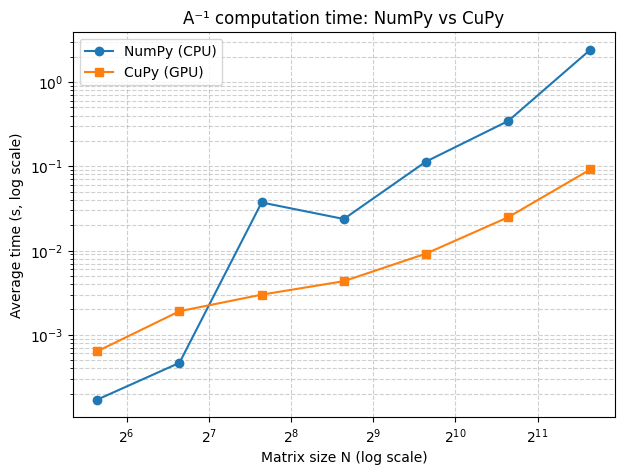

In [ ]:
# ================================================
# 1. A의 inverse matrix 계산 시간 비교 (NumPy vs CuPy)
# ================================================
import time
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
import pandas as pd

def gpu_sync():
    cp.cuda.Stream.null.synchronize()

def make_reg_matrix(N, xp=np, dtype=np.float32, seed=0, reg=1e-3):
    """무작위 행렬에 약한 정칙화(reg*I) 추가"""
    rs = np.random.RandomState(seed)
    A = rs.randn(N, N).astype(dtype)
    A = xp.asarray(A)
    A = A + reg * xp.eye(N, dtype=dtype)
    return A

def bench_inv_numpy(N, reps=2, dtype=np.float32, seed=0, reg=1e-3):
    A = make_reg_matrix(N, xp=np, dtype=dtype, seed=seed, reg=reg)
    _ = np.linalg.inv(A)  # warm-up
    times = []
    for _ in range(reps):
        t0 = time.perf_counter()
        Ainv = np.linalg.inv(A)
        times.append(time.perf_counter() - t0)
    return float(np.mean(times))

def bench_inv_cupy(N, reps=2, dtype=np.float32, seed=0, reg=1e-3):
    A = make_reg_matrix(N, xp=cp, dtype=dtype, seed=seed, reg=reg)
    _ = cp.linalg.inv(A); gpu_sync()  # warm-up
    times = []
    for _ in range(reps):
        t0 = time.perf_counter()
        Ainv = cp.linalg.inv(A)
        gpu_sync()
        times.append(time.perf_counter() - t0)
    return float(np.mean(times))

# ---- 실험 수행 ----
Ns = [50, 100, 200, 400, 800, 1600, 3200]
dtype = np.float32
results = []

for N in Ns:
    try:
        t_np = bench_inv_numpy(N, reps=2, dtype=dtype, seed=1)
    except Exception as e:
        t_np = np.nan
        print(f"[NumPy][N={N}] 실패: {e}")

    try:
        t_cp = bench_inv_cupy(N, reps=2, dtype=dtype, seed=1)
    except cp.cuda.memory.OutOfMemoryError:
        t_cp = np.nan
        print(f"[CuPy][N={N}] 메모리 부족(OOM)")
    except Exception as e:
        t_cp = np.nan
        print(f"[CuPy][N={N}] 실패: {e}")

    results.append((N, t_np, t_cp))

# ---- 결과 정리 ----
df_inv = pd.DataFrame(results, columns=["N", "NumPy_time(s)", "CuPy_time(s)"])
print(df_inv.to_string(index=False, justify="center", col_space=14))

# ---- 시각화 ----
plt.figure(figsize=(7,5))
plt.plot(df_inv["N"], df_inv["NumPy_time(s)"], 'o-', label='NumPy (CPU)')
plt.plot(df_inv["N"], df_inv["CuPy_time(s)"], 's-', label='CuPy (GPU)')
plt.xscale("log", base=2)
plt.yscale("log")
plt.xlabel("Matrix size N (log scale)")
plt.ylabel("Average time (s, log scale)")
plt.title("A⁻¹ computation time: NumPy vs CuPy")
plt.grid(True, which="both", ls="--", alpha=0.6)
plt.legend()
plt.show()


### ✅ (2) 행렬곱 AB 계산 시간 — NumPy vs CuPy (2회 반복 평균)

       N        NumPy_time(s)  CuPy_time(s) 
       50         0.000017       0.000241   
      100         0.000044       0.000172   
      200         0.009996       0.000197   
      400         0.007999       0.000362   
      800         0.017523       0.000647   
     1600         0.117670       0.003335   
     3200         0.513229       0.022848   


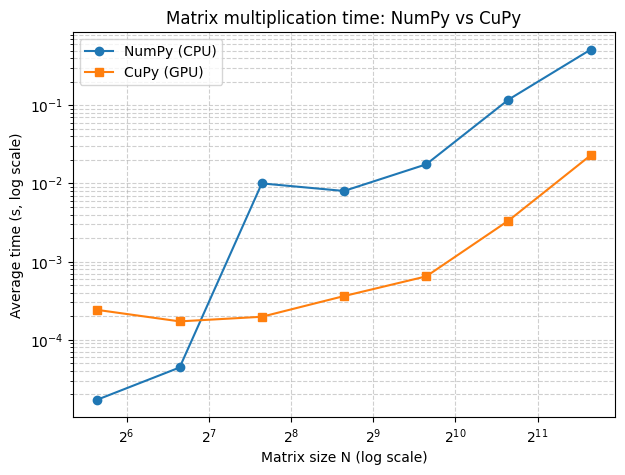

In [ ]:
# ================================================
# 2. 행렬곱 AB 계산 시간 비교 (NumPy vs CuPy)
# ================================================
import time
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
import pandas as pd

def gpu_sync():
    cp.cuda.Stream.null.synchronize()

def bench_matmul_numpy(N, reps=2, dtype=np.float32, seed=0):
    rs = np.random.RandomState(seed)
    A = rs.randn(N, N).astype(dtype)
    B = rs.randn(N, N).astype(dtype)
    _ = np.matmul(A, B)  # warm-up
    times = []
    for _ in range(reps):
        t0 = time.perf_counter()
        AB = np.matmul(A, B)
        times.append(time.perf_counter() - t0)
    return float(np.mean(times))

def bench_matmul_cupy(N, reps=2, dtype=np.float32, seed=0):
    rs = np.random.RandomState(seed)
    A = cp.asarray(rs.randn(N, N).astype(dtype))
    B = cp.asarray(rs.randn(N, N).astype(dtype))
    _ = cp.matmul(A, B); gpu_sync()  # warm-up
    times = []
    for _ in range(reps):
        t0 = time.perf_counter()
        AB = cp.matmul(A, B)
        gpu_sync()
        times.append(time.perf_counter() - t0)
    return float(np.mean(times))

# ---- 실험 수행 ----
Ns = [50, 100, 200, 400, 800, 1600, 3200]
dtype = np.float32
results = []

for N in Ns:
    try:
        t_np = bench_matmul_numpy(N, reps=2, dtype=dtype, seed=2)
    except Exception as e:
        t_np = np.nan
        print(f"[NumPy][N={N}] 실패: {e}")

    try:
        t_cp = bench_matmul_cupy(N, reps=2, dtype=dtype, seed=2)
    except cp.cuda.memory.OutOfMemoryError:
        t_cp = np.nan
        print(f"[CuPy][N={N}] 메모리 부족(OOM)")
    except Exception as e:
        t_cp = np.nan
        print(f"[CuPy][N={N}] 실패: {e}")

    results.append((N, t_np, t_cp))

# ---- 결과 정리 ----
df_mm = pd.DataFrame(results, columns=["N", "NumPy_time(s)", "CuPy_time(s)"])
print(df_mm.to_string(index=False, justify="center", col_space=14))

# ---- 시각화 ----
plt.figure(figsize=(7,5))
plt.plot(df_mm["N"], df_mm["NumPy_time(s)"], 'o-', label='NumPy (CPU)')
plt.plot(df_mm["N"], df_mm["CuPy_time(s)"], 's-', label='CuPy (GPU)')
plt.xscale("log", base=2)
plt.yscale("log")
plt.xlabel("Matrix size N (log scale)")
plt.ylabel("Average time (s, log scale)")
plt.title("Matrix multiplication time: NumPy vs CuPy")
plt.grid(True, which="both", ls="--", alpha=0.6)
plt.legend()
plt.show()


### 그래프 해석

- x축(log₂ N): 행렬 크기 (N) — 로그 스케일로 표시.

- y축(log): 평균 연산 시간 (초).

- 추세

    - 작은 N에서는 CPU(NumPy)가 오히려 빠를 수 있습니다 (GPU 오버헤드).

    - N이 커질수록 GPU(CuPy)의 곡선이 CPU 대비 완만해지며 성능 우위가 뚜렷하게 나타납니다.

# 3) N이 커질수록 NumPy와 CuPy 수행시간 격차가 커지는 이유

1. **연산 복잡도와 병렬화 효율**
    - 행렬곱/역행렬 등 선형대수 핵심 연산은 전형적으로 **O(N³)** 시간복잡도입니다.
    - N이 작을 때는 커널 런치·호스트↔디바이스 전송 등 **고정 오버헤드**가 비중을 크게 차지하여 GPU의 장점이 묻힙니다.
    - N이 커질수록 연산량이 급증하여 **병렬 처리량(스루풋)**이 지배적이 되고, 수천~수만 규모에서는 **GPU의 대규모 코어·고대역 메모리**가 본격적으로 빛을 발합니다.
2. **산술집중도(Arithmetic Intensity) 증가**
    - 큰 N에서는 **메모리 접근 대비 연산 횟수**가 상대적으로 증가(산술집중도↑)하여, GPU의 대규모 연산 유닛이 더 효율적으로 활용됩니다.
    - 이때 커널 런치·동기화 비용은 **분모(총 시간)**가 커지면서 **상대적으로 희석**됩니다.
3. **라이브러리 최적화와 하드웨어 특성**
    - CuPy의 선형대수는 NVIDIA의 **cuBLAS/cuSolver** 등 고도로 최적화된 라이브러리를 사용합니다.
    - 큰 행렬에서는 **타일링, 블록 분해, 매크로/마이크로 커널 최적화**가 더 높은 효율로 작동하며, 최신 GPU 아키텍처에서는 특정 정밀도에서 **가속 유닛(예: 텐서코어/특정 매트릭스 엔진)**가 활용되어 격차가 더 벌어질 수 있습니다. *(정밀도/환경에 따라 달라질 수 있습니다.)*
4. **CPU 자원 한계 vs. GPU 대규모 병렬성**
    - 일반 CPU는 소수의 코어와 제한된 메모리 대역폭을 갖습니다.
    - GPU는 수천 개 이상의 연산 유닛과 높은 메모리 대역폭을 활용하므로, **N이 커질수록** CPU 대비 **스케일링 이점**이 커집니다.

N이 커질수록 NumPy와 CuPy 간의 수행 시간 격차가 커지는 이유는 연산 복잡도와 병렬화 효율의 차이에 기인하는 현상으로 정의됨. 행렬 연산은 일반적으로 O(N³)의 계산 복잡도를 가지며, 작은 N에서는 커널 실행 준비나 데이터 전송과 같은 고정 오버헤드가 전체 실행 시간에서 차지하는 비중이 커서 GPU의 병렬 처리 이점이 드러나지 않음. 그러나 N이 커질수록 총 연산량이 폭발적으로 증가하며 GPU의 대규모 병렬 연산 구조가 그 복잡도 증가를 효율적으로 흡수하게 되는 구조임. 이 과정에서 산술집중도(arithmetic intensity)가 증가하여 메모리 접근 대비 연산 비율이 높아지고, 수천 개의 CUDA 코어가 동시에 연산을 수행함으로써 처리 효율이 비약적으로 상승함. CuPy는 내부적으로 NVIDIA의 cuBLAS 및 cuSolver와 같은 고성능 라이브러리를 사용하여 블록 분해, 타일링, 커널 최적화와 같은 하드웨어 친화적 연산을 수행하며, Tensor Core와 같은 전용 가속 유닛을 활용함으로써 대규모 행렬 연산에서 CPU 대비 월등한 처리량을 달성함. 반면 CPU는 상대적으로 적은 수의 코어와 제한된 메모리 대역폭을 가지므로 대규모 연산에서 확장성의 한계를 드러내는 구조임. 따라서 작은 N에서는 CPU가 더 효율적일 수 있으나, N이 증가함에 따라 GPU의 병렬성, 대역폭, 라이브러리 최적화가 지배적인 요인으로 작용하여 수행 시간의 격차가 기하급수적으로 확대되는 현상으로 요약됨.